# Modeling a volcanic plumbing system

We will explore a simple lumped, or compartmental model, of a volcano. In volcanology, like in many other Earth Science disciplines, such simple models serve multiple purposes. Here our goals are to describe the essential parts of a complex geophyscial system and to interpret observations.

We will follow the first two sections of [Segall's review paper](https://doi.org/10.1098/rsta.2018.0158) to model a magma chamber connected to a deep reservoir, exploring cycles of repeated inflation and eruption of a volcano in Iceland.

Initially, we focus on the pressurization of the magma chamber due to the influx of magma from below.

## Magma chamber connected to a deep reservoir



We will consider a spherical magma chamber that is connected to a deep reservoir through a vertical conduit. When the pressure in the chamber is sufficiently low compared to that of the reservoir, magma will flow up the conduit.


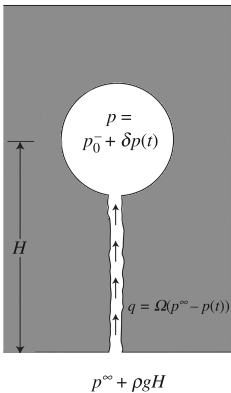

The pressure in the magma chamber at time $t$ is $p(t)$. Recall that the pressure is the force per unit area, with dimensions M L$^{−1}$ T$^{−2}$ and SI units Pascal. We decompose

$p(t) = p^−_0 + \delta p(t)$

into a reference pressure $p^-_0$ (say, a large pressure that may initiate an eruption) and a deviation $\delta p(t)$.

The pressure in the deep reservoir $p_{\mathrm{deep}}$ is assumed not to change with time. We partition it into two terms

$p_{\mathrm{deep}} = p^{\infty} + \rho g H$,

where $\rho$ is the (average) magma density, $g$ is the gravitational acceleration and $H$ is the height of the chamber above the reservoir. Make sure you know the dimensions and units of all quantities we have introduced so far.

## Equilibrium

The rationale for the decomposition of $p_{\mathrm{deep}}$ is the ease of interpretation when the magma is at rest. In magmastatic equilibrium (no flow), the pressure increases with depth due to the force exerted by the weight of the overlying materials: they press down.

We now analyze the forces acting on a magma-filled cylinder of area $A$ and height $H$. You can imagine its base to be at the conduit$-$reservoir interface and its top to be in the middle of the chamber. The total force acting on the magma in the cylinder is

$F_{\mathrm{tot}} = F_{\mathrm{top}} + F_{\mathrm{bottom}} + F_{\mathrm{weight}}$.

Here, the force acting on the top, $F_{\mathrm{top}} = -p A$, is due to the pressure in the chamber pushing down (negative sign). Similarly, $F_{\mathrm{bottom}} = p_{\mathrm{deep}} A$ is due to the pressure in the reservoir pushing up (positive sign). The mass of the cylinder, $\rho A H$ exerts a weight $F_{\mathrm{weight}} = g \rho A H$, which is also pushing down. In equilibrium, the three forces cancel, viz. $F_{\mathrm{tot}} = 0$.

Our decomposition allows us to deduce that in hydrostatic equilibrum,

$p(t) = p^{\infty}$.

### In pairs
Determine the direction and magnitude of the total force when $p(t) < p^{\infty}$. In light of Newton's law, what will happen?




## Modeling chamber recharge

### Flow into the chamber

We want to determine the flow from the reservoir into the chamber. We refer to the mass flow rate as $q_{\mathrm{in}}$ or $q$. It is the mass of the magma that passes into the magma chamber per unit time. Its dimension is M T$^{−1}$, its SI units are kg/s. For convenience, we choose a positive sign to correspond to a flux into the reservoir.

The flow rate can be modeled as

$q_{\mathrm{in}} = \Omega (p^{\infty} - p(t))$,

where $\Omega$ is a conductance with SI units kg Pa$^{−1}$ s$^{−1}$. The large $\Omega$, the greater the flow for a given pressure difference. For instance, the wider the conduit, the greater we expected $\Omega$ to be. When the pressure difference is zero, there is no flow. When $p^{\infty} > p(t)$, magma will rise into the magma chamber.

To get a more intuitive idea of how the flow rate depends on $\Omega$ and the pressure difference, we use Python.

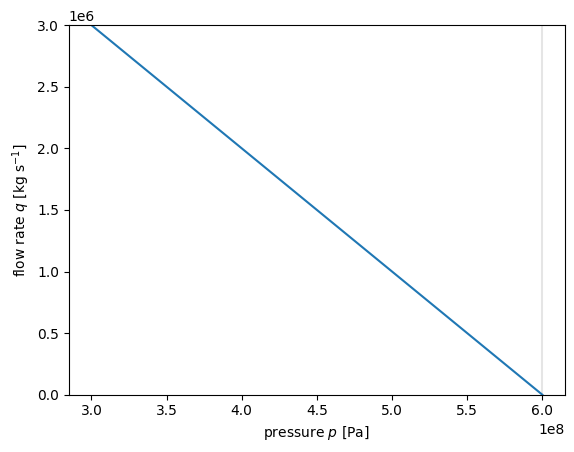

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


p_0 = 3e8
p_inf = 6e8 #Pa
Omega = 1e-2 # kg/(Pa s)
p = np.linspace(p_0, p_inf) # trying out different values of p between

def flow_rate(p, p_inf=p_inf, Omega=Omega):
  return Omega * (p_inf - p)

q_in = flow_rate(p)

fig, ax = plt.subplots()
ax.axvline(p_inf, c='#aaaaaa', alpha=0.3)

ax.plot(p, q_in)
ax.ticklabel_format(style='sci', scilimits=(0,0))
ax.set_xlabel('pressure $p$ [Pa]')
ax.set_ylim(0, max(q_in))
_ = ax.set_ylabel('flow rate $q$ [kg s$^{-1}$]')

The lower the pressure $p$, the greater the flow rate. Flow ceases when the chamber and the deep reservoir are in magmastatic equilibrium, $p = p^{\infty}$ (vertical line).

### 😱 Insight into the flow law


One way to think of this flow rate equation is that it is a first-order approximation, with $\Omega$ a parameter to be determined empirically. A complementary, more physical way, is to "derive" the relation assuming laminar, steady-state flow of a Newtonian fluid. The fluid is not accelerated because the force $F_{\mathrm{top}} + F_{\mathrm{bottom}} + F_{\mathrm{weight}}$ is balanced by a viscous drag/friction force. For the specific case of flow in a long cylinder, the [Hagen-Poiseuille law](https://en.wikipedia.org/wiki/Hagen%E2%80%93Poiseuille_equation) can be obtained. It predicts that $\Omega \sim R^4\,\eta^{-1}\,H^{-1}$: It increases rapidly with the radius $R$, decreases with the kinematic viscosity ("thickness") $\eta$ of the magma, and decreases the longer the conduit.

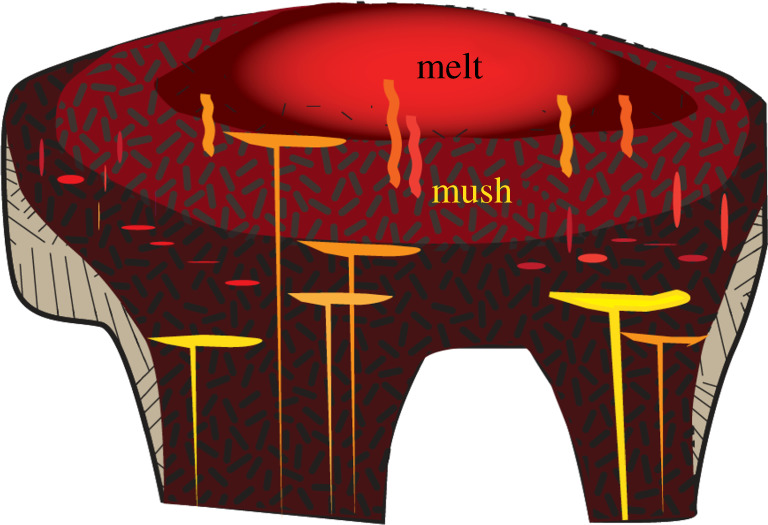


*Supply of magma to the chamber from below is complex and assumptions are required to model it. Our assumption that the flow rate is proportional to the pressure difference is one of convenience and not intended to do justice to the complexity. From Cashman et al. [15].*

## Modeling chamber inflation and pressurization

### Conservation of mass

To track how much magma has accumulated within our chamber, we need to compare the inflow with the outflow

$\frac{\mathrm{d}m}{\mathrm{d}t} = q_{\mathrm{in}} - q_{\mathrm{out}}$.

For constant flow rates, the change in mass of a time interval $\Delta t$, $\Delta m = (q_{\mathrm{in}} - q_{\mathrm{out}})\Delta t$. In our case, the magma cannot leave the chamber (yet), so $q_{\mathrm{out}} = 0$. When $q_{\mathrm{in}} > q_{\mathrm{out}}$, or for us $q_{\mathrm{in}} > 0$, mass accumulates in the chamber. As $q_{\mathrm{in}}$ is the mass of magma supplied per unit time, in a time interval $\Delta t$, the mass of magma in the chamber increases by $\Delta m = q_{\mathrm{in}} \Delta t$.

To make sure you understand this equation, write out the units of all the quantities involved and check whether they make sense.


## Pressure-mass relationship

As mass accumulates in the chamber, the pressure will increase as the chamber inflates. This is not unlike inflating a balloon or a bicycle tire. It can be modeled as

$\frac{\mathrm{d}m}{\mathrm{d}t} = \rho V_0 \beta \frac{\mathrm{d}p}{\mathrm{d}t}$,

where $\rho$ is the initial density of the magma, $V_0$ is the initial volume of the chamber, and $\beta$ is the system compressibility. The greater $\beta$, the smaller the increase in pressure for a fixed increase in mass. The system compressibility combines the effect of the magma being compressible (it becomes denser the greater the pressure) and the host rock surrounding the chamber being compressible (allowing the chamber to grow in size). You can consult the Segall paper (equation 1.2) for more information.

## Putting it all together

We are now ready to model how the pressure and mass in the magma chamber change over time. Plugging the pressure-mass relationship into the flow law, we get

$\frac{\mathrm{d}p}{\mathrm{d}t} = \frac{1}{\tau} (p^{\infty} - p(t))$,

where $\tau = \rho V_0 \beta / \Omega$ is a parameter with dimension T. It determines how long it takes for the chamber to inflate.


## Solution


The solution to the equation is with the initial condition $p(0) = p_0$ is

$p(t) = p^{\infty} - (p^{\infty} - p_0) \exp(-\frac{t}{\tau})$.

Beware the typo in Eq. 1.4. in the Segall paper.

😱 Can you derive the solution from scratch?

## Numerical simulation

The following code simulates and plots the pressure $p(t)$ in the inflating chamber, starting from an initial value $p_0 < p^{\infty}$.

How long does it take for the deviation from $p^{\infty}$ to be reduced to a fraction (say, 1/3) of the initial value? How does this compare to $\tau$?

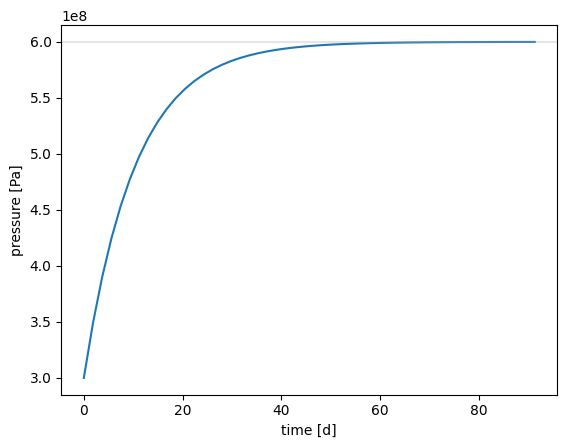

In [11]:
year = 60 * 60 * 24 * 365.25 # length of a year in s

rho = 3e3  # kg/m3
V_0 = 1e9  # m3
beta = 3e-9  # m2/N

def simulate_inflation(p_0, t, rho=rho, V_0=V_0, beta=beta, Omega=Omega):
  tau = rho * V_0 * beta / Omega
  p = p_inf - (p_inf - p_0) * np.exp(-t / tau)
  return p

t = np.linspace(0, 0.25 * year)
p = simulate_inflation(p_0, t)

fig, ax = plt.subplots()
t_days = t / year * 365
ax.plot(t_days, p)
ax.axhline(p_inf, alpha=0.3, c='#aaaaaa')
ax.set_xlabel('time [d]')
_ = ax.set_ylabel('pressure [Pa]')


## Think-pair-share:

The timeseries below shows the tilt at the surface near a magma chamber. We will assume its changes are proportional to pressure changes in the chamber.

Compare the evolution right after intrusions or eruptions to the model predictions. What aspects of the observations can our model capture of the recharge process? What model parameters can you constrain from these observations?

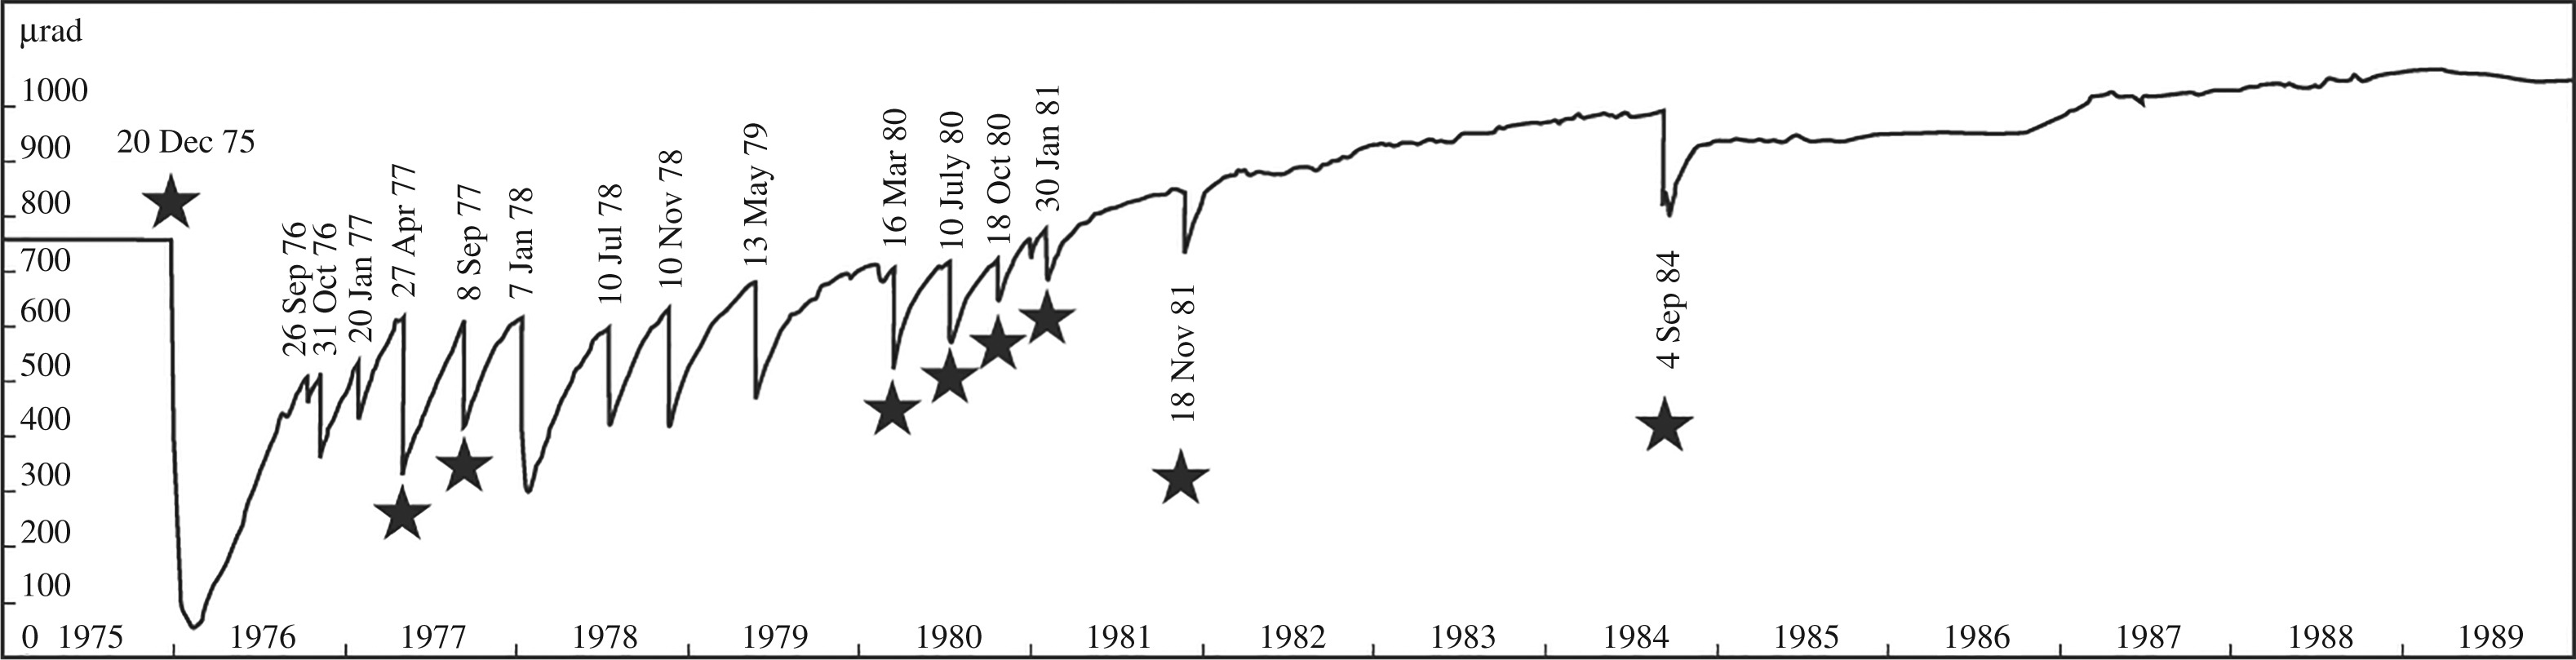

*Water tube tilt record at [Krafla](https://volcano.si.edu/volcano.cfm?vn=373080) power plant in Iceland. Positive tilt corresponds to increasing pressure because the pressurized magma makes the surface above the chamber bulge. The sudden drops are either intrusions into the adjacent rift zone or eruptions (stars). After Sturkell et al.*



## Group work

Below you see a conceptual diagram that extends our model of the post-eruption (inflation) phase (c) with an eruptive process. The idea is that once a threshold pressure $p_0^-$ has been reached (a), an eruption is initiated (b), for instance by the propagation of a dike to the surface. Intrusions may also be triggered by large overpressures. Our conceptual model does not consider the details of the eruption/intrusion mechanisms. It postulates that the removal of mass $\delta m$ during the eruption has caused a drop in the pressure to $p_0^- + \delta p(0^+)$ immediately after the eruption. The pressure drop promotes influx of magma from the deep reservoir (c).

Using the diagram as a starting point, explain the quasiperiodic behavior observed in 1977-1980. The goal is to link the time series with the quantitative model of pressurization and the broader conceptual model. One or several figures that relate salient aspects of the time series with a mechanistic description are a compelling approach.

In an effort to "explain" the sawtooth pattern observed in the data, you can ask yourself questions such as when a rapid decrease in tilt occurs and why the tilt does not reach a constant value, indicative of steady state conditions.

Bonus question: Can you explain what the time between tilt drops and thus eruptions (or dike propagation events) depends on?

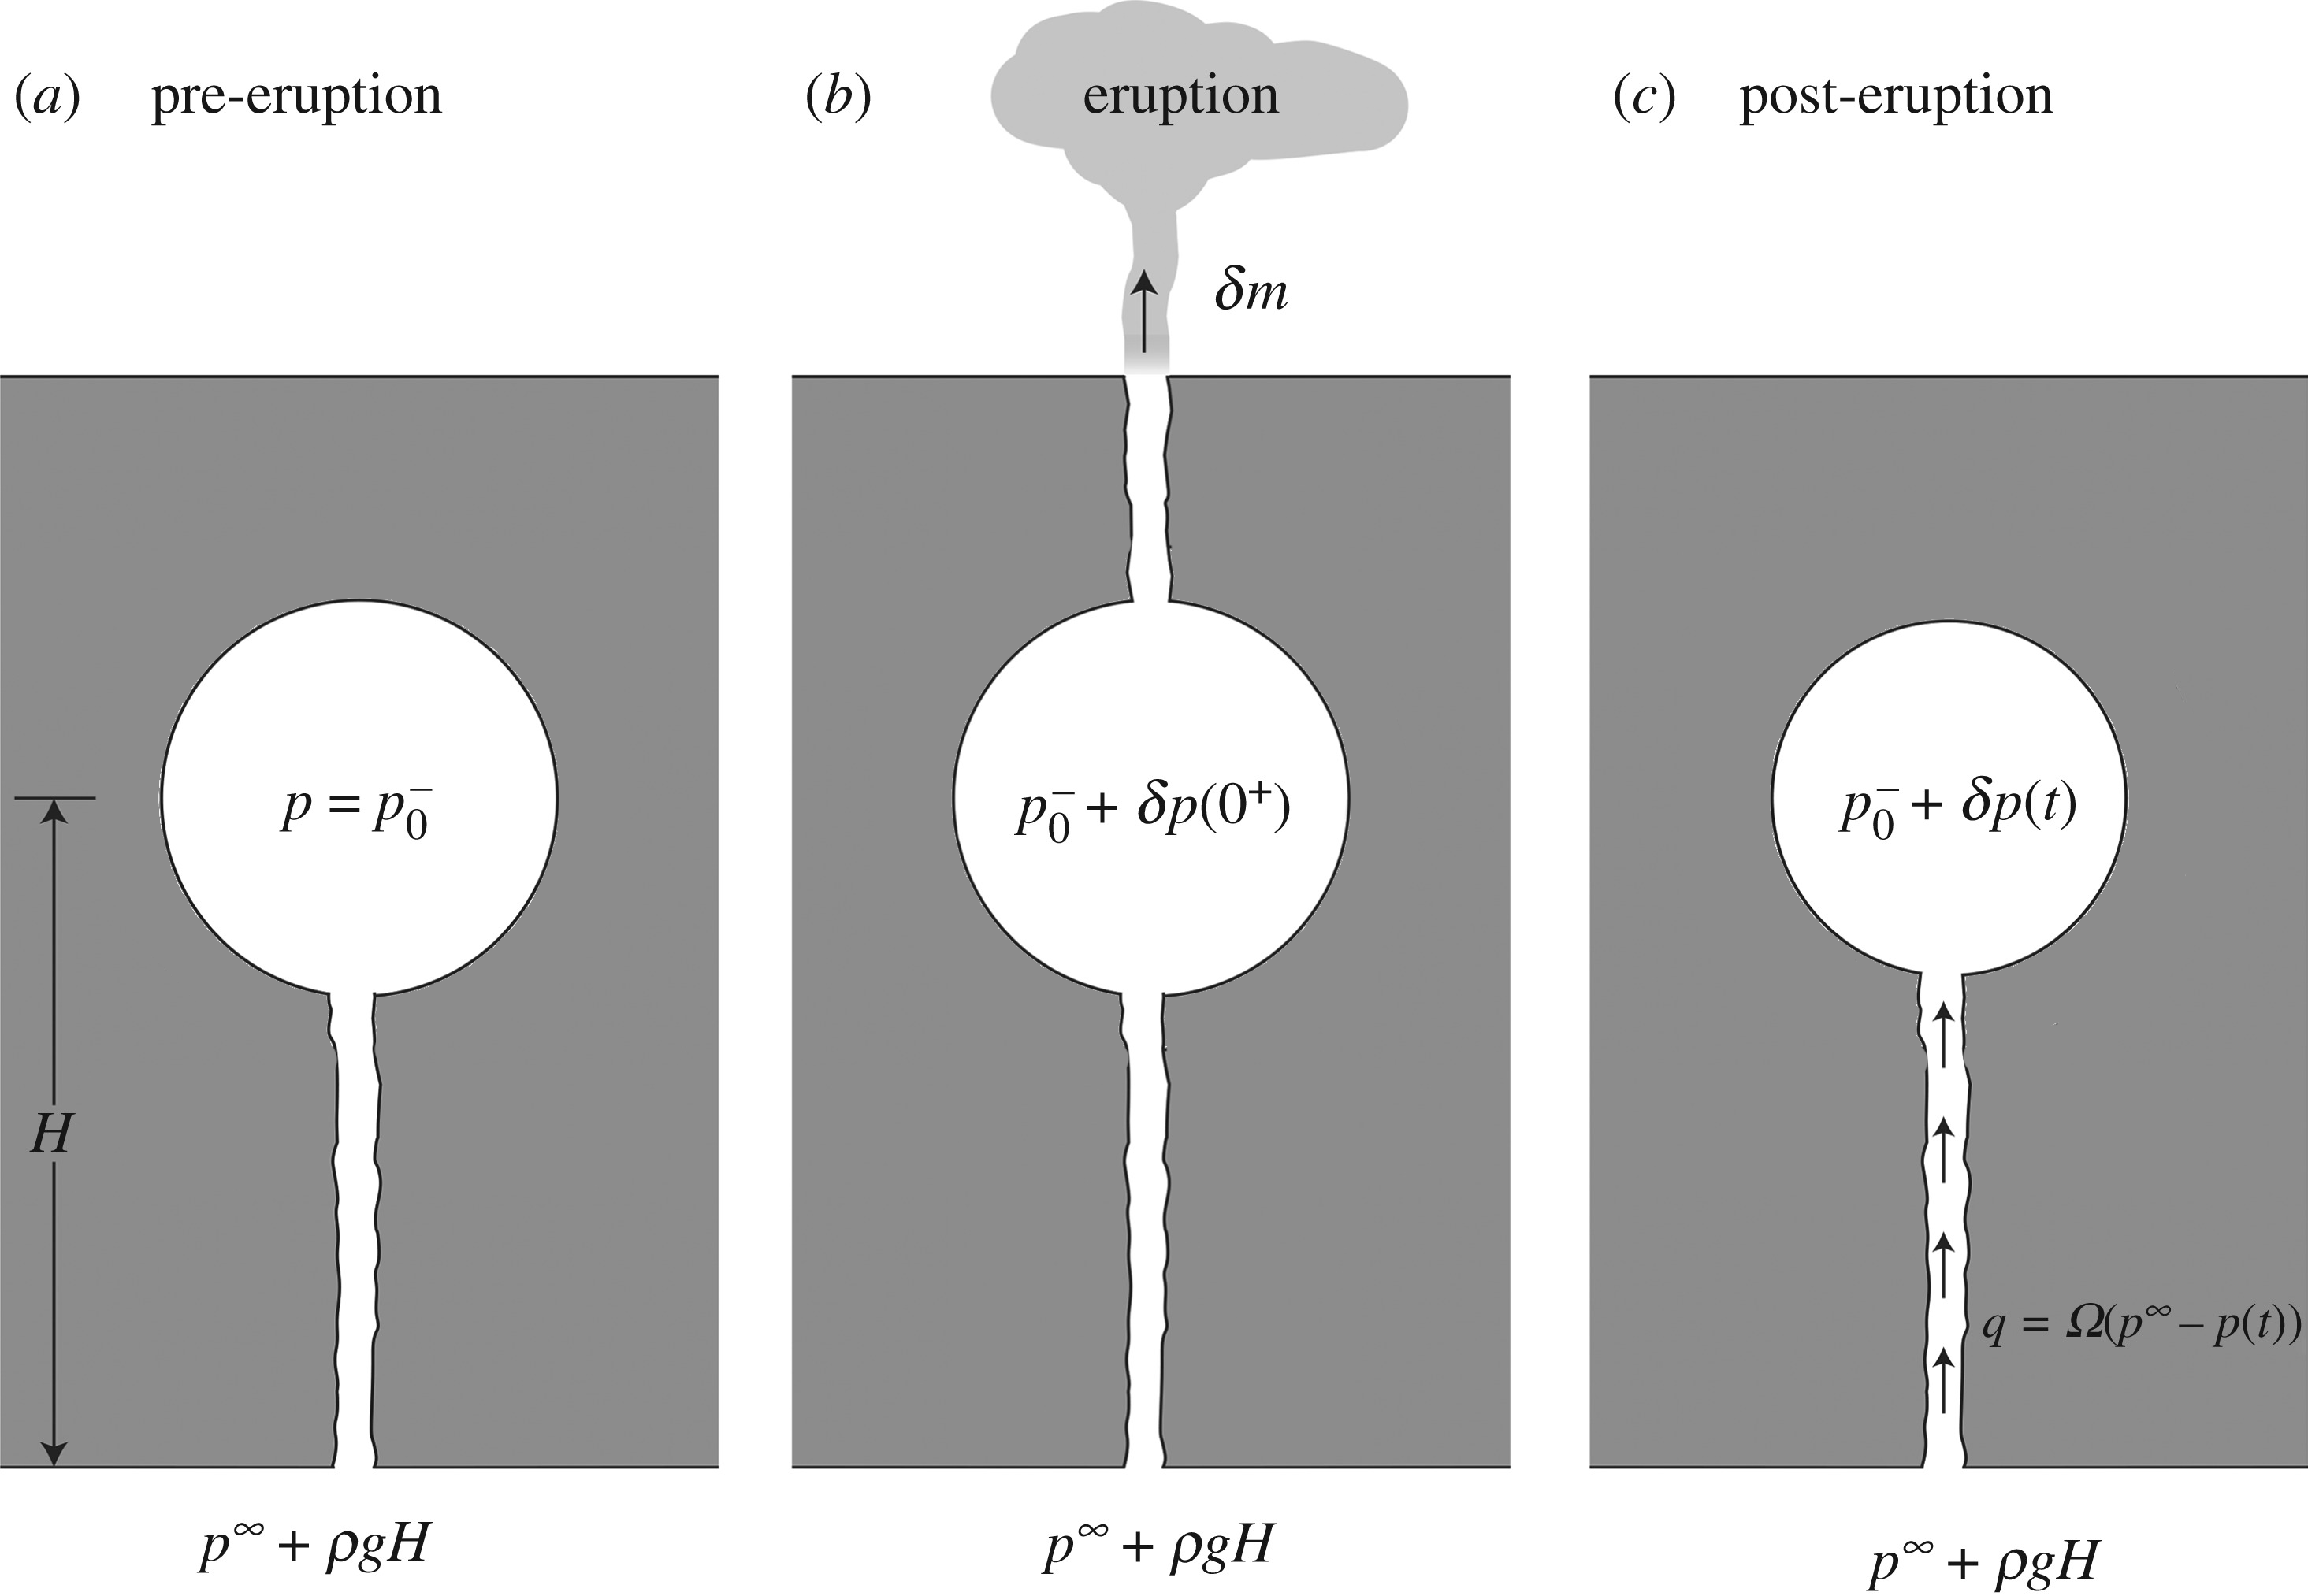

*Adapted from Segall.*